1. Upload and Extract Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving PRAICP-1002-TrafSignDetc.zip to PRAICP-1002-TrafSignDetc.zip


 Unzip the dataset

In [2]:
!unzip PRAICP-1002-TrafSignDetc.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/5/00005_00053_00010.png  
  inflating: train/5/00005_00053_00011.png  
  inflating: train/5/00005_00053_00012.png  
  inflating: train/5/00005_00053_00013.png  
  inflating: train/5/00005_00053_00014.png  
  inflating: train/5/00005_00053_00015.png  
  inflating: train/5/00005_00053_00016.png  
  inflating: train/5/00005_00053_00017.png  
  inflating: train/5/00005_00053_00018.png  
  inflating: train/5/00005_00053_00019.png  
  inflating: train/5/00005_00053_00020.png  
  inflating: train/5/00005_00053_00021.png  
  inflating: train/5/00005_00053_00022.png  
  inflating: train/5/00005_00053_00023.png  
  inflating: train/5/00005_00053_00024.png  
  inflating: train/5/00005_00053_00025.png  
  inflating: train/5/00005_00053_00026.png  
  inflating: train/5/00005_00053_00027.png  
  inflating: train/5/00005_00053_00028.png  
  inflating: train/5/00005_00053_00029.png  
  inflating: train/5/00005_00054_00000.png  
  in

 2. Import Required Libraries

In [6]:
import os
os.listdir('/content')

['.config',
 'Train',
 'Meta.csv',
 'meta',
 'train',
 'PRAICP-1002-TrafSignDetc.zip',
 'Test.csv',
 'Test',
 'Train.csv',
 'test',
 'Meta',
 'sample_data']

In [24]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


3. Load Training Data

In [25]:
train_df = pd.read_csv('/content/Train.csv')
print("Total training samples:", len(train_df))
print(train_df.head())

images = []
labels = []

for i in range(len(train_df)):
    img_path = os.path.join('/content', train_df['Path'][i])
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (32, 32))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        images.append(img)
        labels.append(train_df['ClassId'][i])

# Convert to NumPy arrays
X = np.array(images, dtype='float32') / 255.0
y = to_categorical(labels, num_classes=43)

print("Dataset shape:", X.shape)

Total training samples: 39209
   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  


 4. Train-Validation Split

In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 31367
Validation samples: 7842


 5. Data Augmentation

In [27]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

datagen.fit(X_train)


6. Build CNN Model

In [28]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(43, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,126,859 (4.30 MB)

 Trainable params: 1,126,155 (4.30 MB)

 Non-trainable params: 704 (2.75 KB)

7. Callbacks

In [29]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_loss',
        save_best_only=True
    )
]


8. Train the Model

In [30]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
979/981 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3652 - loss: 2.4687

981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - accuracy: 0.5547 - loss: 1.5821 - val_accuracy: 0.8730 - val_loss: 0.3910
Epoch 2/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8450 - loss: 0.5077

981/981 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.8782 - loss: 0.4007 - val_accuracy: 0.9893 - val_loss: 0.0461
Epoch 3/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9264 - loss: 0.2370

981/981 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.9359 - loss: 0.2062 - val_accuracy: 0.9932 - val_loss: 0.0285
Epoch 4/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9565 - loss: 0.1470

981/981 ━━━━━━━━━━━━━━━━━━━━ 27s 28ms/step - accuracy: 0.9557 - loss: 0.1468 - val_accuracy: 0.9959 - val_loss: 0.0138
Epoch 5/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9627 - loss: 0.1235

981/981 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9630 - loss: 0.1210 - val_accuracy: 0.9966 - val_loss: 0.0130
Epoch 6/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9675 - loss: 0.1022 - val_accuracy: 0.9954 - val_loss: 0.0151
Epoch 7/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.9739 - loss: 0.0862 - val_accuracy: 0.9931 - val_loss: 0.0242
Epoch 8/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9735 - loss: 0.0887

981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9750 - loss: 0.0840 - val_accuracy: 0.9986 - val_loss: 0.0051
Epoch 9/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9789 - loss: 0.0680 - val_accuracy: 0.9960 - val_loss: 0.0109
Epoch 10/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9791 - loss: 0.0680

981/981 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9777 - loss: 0.0702 - val_accuracy: 0.9989 - val_loss: 0.0043
Epoch 11/30
980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9819 - loss: 0.0609

981/981 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9812 - loss: 0.0625 - val_accuracy: 0.9992 - val_loss: 0.0031
Epoch 12/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9819 - loss: 0.0580 - val_accuracy: 0.9978 - val_loss: 0.0087
Epoch 13/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.9822 - loss: 0.0568 - val_accuracy: 0.9987 - val_loss: 0.0048
Epoch 14/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9842 - loss: 0.0500 - val_accuracy: 0.9991 - val_loss: 0.0043
Epoch 15/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9843 - loss: 0.0492 - val_accuracy: 0.9991 - val_loss: 0.0050
Epoch 16/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9884 - loss: 0.0380

981/981 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9871 - loss: 0.0420 - val_accuracy: 0.9991 - val_loss: 0.0028
Epoch 17/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9866 - loss: 0.0426 - val_accuracy: 0.9990 - val_loss: 0.0041
Epoch 18/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.9865 - loss: 0.0430 - val_accuracy: 0.9983 - val_loss: 0.0044
Epoch 19/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.9873 - loss: 0.0395 - val_accuracy: 0.9991 - val_loss: 0.0040
Epoch 20/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9874 - loss: 0.0415 - val_accuracy: 0.9994 - val_loss: 0.0033
Epoch 21/30
981/981 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9872 - loss: 0.0422 - val_accuracy: 0.9995 - val_loss: 0.0030


9. Plot Training Results

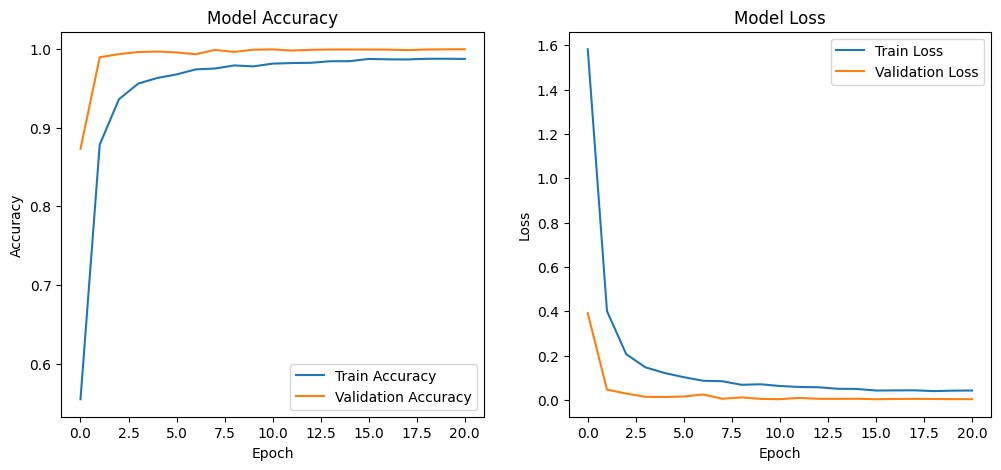

In [31]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


10. Evaluate on Test Dataset

In [32]:
test_df = pd.read_csv('/content/Test.csv')

test_images = []
test_labels = []

for i in range(len(test_df)):
    img_path = os.path.join('/content', test_df['Path'][i])
    img = cv2.imread(img_path)

    if img is not None:
        img = cv2.resize(img, (32, 32))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        test_images.append(img)
        test_labels.append(test_df['ClassId'][i])

X_test = np.array(test_images, dtype='float32') / 255.0
y_test = to_categorical(test_labels, num_classes=43)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 72.00%


11. Save Final Model

In [33]:
model.save('traffic_model.h5')
print("Model saved as traffic_model.h5")

Model saved as traffic_model.h5


12. Predict on a Sample Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


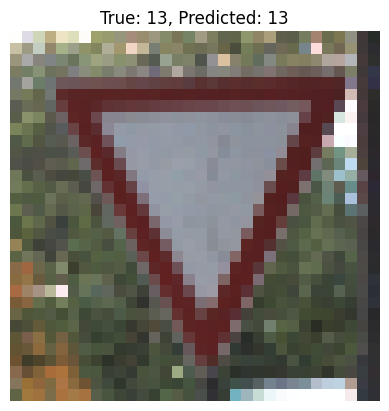

In [34]:
import random

idx = random.randint(0, len(X_test) - 1)
sample_image = X_test[idx]
true_label = np.argmax(y_test[idx])

prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_label = np.argmax(prediction)

plt.imshow(sample_image)
plt.title(f"True: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()